# 单形重心试验设计法

In [1]:
# Preparing
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sn;sn.set(font='WenQUanYi Micro Hei')

In [2]:
# my ternary implement
import matplotlib.tri as tri
corners = np.array([[0, 0], [1, 0], [0.5, 0.75**0.5]])  # cos(30)
triangle = tri.Triangulation(corners[:, 0], corners[:, 1])
# Mid-points of triangle sides opposite of each corner
midpoints = [(corners[(i + 1) % 3] + corners[(i + 2) % 3]) / 2.0
             for i in range(3)]


def xy2bc(xy, tol=1.e-3):
    '''Converts 2D Cartesian coordinates to barycentric.'''
    s = [(corners[i] - midpoints[i]).dot(xy - midpoints[i]) / 0.75
         for i in range(3)]
    return np.clip(s, tol, 1.0 - tol)


def tick_txy(location, width=1.0, size=20):
    height = width * 0.75**0.5
    if location == 'left':
        xy = np.array((
            np.arange(0, width / 2 / size * (size + 1),
                      width / 2 / size),
            np.arange(0, height / size * (size + 1), height / size),
        ))
        return xy[0, :][::-1], xy[1, :][::-1]
    if location == 'right':
        xy = np.array((
            np.arange(0.5, 0.5 + width / 2 / size *
                      (size + 1), width / 2 / size),
            np.arange(0, height / size * (size + 1), height / size),
        ))
        return xy[0, :][::-1], xy[1, :]
    if location == 'bottom':
        xy = np.array((
            np.arange(0, width / size * (size + 1), width / size),
            np.array((0.0,) * (size + 1)),
        ))
        return xy[0, :], xy[1, :]


def tick_labels(scale=100, size=20):
    return [str(int(i)) for i in \
            np.arange(0, scale / size * (size + 1), scale / size)]


def plot_tri_contourf(f, nlevels=200, subdiv=8, **kwargs):
    #scale, zoom, Xnames=('x1', 'x2', 'x3'), size=(10, 8),
    #fontsize=20, **args
    refiner = tri.UniformTriRefiner(triangle)
    trimesh = refiner.refine_triangulation(subdiv=subdiv)
    pvals = [f(xy2bc(xy))
             for xy in zip(trimesh.x, trimesh.y)]
    fig = plt.figure()
    ax = fig.add_subplot(111,aspect = 'equal')
    ax.triplot(triangle, color='black')
    trimap = ax.tricontourf(trimesh, pvals, nlevels, **kwargs)
    offset = 0.02
    linewidth = 1.
    for x, y, s in zip(*tick_txy('left'), tick_labels()):
        ax.text(x - offset / 2, y + 0.75**0.5 * offset, s,
                verticalalignment='center',
                horizontalalignment='right')
        ax.plot((x, x - offset / 2), (y, y + 0.75**0.5 * offset),
                '-', lw=linewidth, color='black')
    for x, y, s in zip(*tick_txy('right'), tick_labels()):
        ax.text(x + offset / 2, y, s,
                verticalalignment='center',
                horizontalalignment='left')
        ax.plot((x, x + offset/2), (y, y),
                '-', lw=linewidth, color='black')
    for x, y, s in zip(*tick_txy('bottom'), tick_labels()):
        ax.text(x - offset/2, y - 0.75**0.5 * offset, s,
                verticalalignment='top',
                horizontalalignment='center')
        ax.plot((x, x - offset/2), (y, y - 0.75**0.5 * offset),
                '-', lw=linewidth, color='black')
    '''
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", "5%", pad="-8%")
    fig.colorbar(trimap, cax=cax)
    '''
    fig.colorbar(trimap)
    ax.set_aspect('equal')
    fig.tight_layout(pad=0)
    ax.axis('equal')
    #ax.set_xlim(0, 1)
    #ax.set_ylim(-0.02, 0.75**0.5+0.02)
    ax.axis('off')
    return fig

## 介绍及概念

单纯形重心设计法是一种效率较高的混料试验统计模型，可用来设计试验，它能根据试验点和响应值给出响应曲面（模型）。
该法具有较高的精度和可靠性，以及较少的试验量，很适合混料试验设计。

**概念**
- 单形（单纯形）：为空间中顶点比维数多1的凸多边形，比如〇维的点、一维的线段，二维的三角形、三维的四面体等。
- 响应值：某一试验点试验后的评价。
- 三角坐标系：由三角形构成的坐标系，顶点代表对应成分的最大值。特点是三角形内（含边）一点P(ax,by,cz)，过P作三条对三角形边的平行线，可以确定x,y,z的比例。如图所示。
![](images/1trco.png)
- 等值线：将某一指标中数值相同的点连线。等值线实际上是将空间（Z轴）投影到平面（XY轴）的表示。如下图。
![](images/1eq.png)

## 单形格子设计


设试验中考察的指标为$y$，那么$y$与$p$个因子$x_1,x_2,...,x_p$的关系可以表示为：$y=f(x_1,x_2,⋯,x_p )+\varepsilon$

其中，$\varepsilon$是随机误差，且要保证$0\leq x\leq 1 ,\sum_{i=1}^p x_i=1$

称$y=f(x_1,x_2,\dots,x_p)$为响应函数，当响应函数中的未知参数用估计值代替后便得到回归方程，也称响应曲面方程。

由于$f(x_1,x_2,...,x_p)$形式往往是未知的，通常用$x_1,x_2,\dots,x_p$的一个$d$次多项式表示，此时一个混料试验由因子数$p$与响应多项式的次数$d$来确定，以后用$M\{p,d\}$表示一个混料试验。
即 ：（公式1）
$$
\begin{align}
y=f(x_1,x_2,\dots,x_p) 
=\sum_{i=1}^p\eta_ix_i+\sum_{i\leq j}\eta_{ij}x_ix_j+\sum_{i\leq j\leq k}\eta_{ijk}x_ix_jx_k+\cdots
\end{align}
$$

单形格子设计是Scheffé提出的一种混料设计。$M\{p,d\}$的单形格子设计，为$d$阶格子设计，它将单形的边划分成$d$等份，在等分点做与其它边平行的直线，形成许多格子，故名单形格子设计。

$p=1$，为点；$p=2$，为线段；$p=3$，为三角形；$p=4$，为四面体；$p=5$，为超四面体……

举例：$p=3$，一阶、二阶和三阶单形格子设计的点分布图。
![](images/1ex.png)

## 单形重心设计


单形格子设计的缺陷是在$M\{p,d\}$单形格子设计中，当$d>2$时某些混料设计中格子点的非零坐标（如$M\{3,3\}$中的8、9及其对称点）并不相等，这种非对称性会使某些点对回归系数的估计产生较大的影响，为改进这一点，Scheffé提出了一种只考虑有相等非零坐标的单形重心设计，既消除了以上缺陷，又不至于试验点数太多。

*单形重心设计的试验点为$1$到$p$个顶点的重心，顶点本身就是重心，两个顶点的重心是它们连线的中点，三个顶点的重心是它们组成正三角形的中心，……，$p$个顶点的重心就是该单形的中心。*

此时给出的多项式模型称为Scheffé单形重心设计的多项式模型。具体如下，注意最后一项。（公式2）
$$
\begin{align}
y=f(x_1,x_2,\cdots,x_p) 
=\sum_{i=1}^p\eta_ix_i+\sum_{i\leq j}\eta_{ij}x_ix_j+\sum_{i\leq j\leq k}\eta_{ijk}x_ix_jx_k+\cdots+\eta_{12\cdots p}x_1x_2\cdots x_p
\end{align}
$$

其中，若$p=3$，由于只取重心试验，故有：
$$
\begin{align}
y=f(x_1,x_2,x_3) 
=\sum_{i=1}^3\eta_ix_i+\sum_{i\leq j}\eta_{ij}x_ix_j+\eta_{123}x_1x_2x_3
\end{align}
$$
分别取$x_i=1, x_j=x_k=0;
x_i=x_𝑗=1/2,x_k=0;
x_i=x_𝑗=x_k=1/3$,分别代入单形重心设计的多项式，可得各系数与各响应值的关系。

各系数与各响应值的关系如下：
$$
\begin{align}
\begin{cases}
\eta_i=y_i \\
\eta_{ij}=2\big(2^1y_{ij}-1^1(y_i+y_j)\big) \\
\eta_{ijk}=3\big(3^2y_{ijk}-2^2(y_{ij}+y_{ik}+y_{jk})+1^2(y_i+y_j+y_k)\big)
\end{cases}
\end{align}
$$

其实经过推导，可以获得一般公式的，若$S_r=\{i_1,i_2,\cdots,i_r\}$为关于$(1,2,\cdots,p)$的某个$r$元素的子集，则:（公式3)
$$
\begin{align}
\eta_{S_r}=r\Big(\sum_{t=1}^r(-1)^{r-t}t^{r-1}L_t(S_r)\Big)
\end{align}
$$

其中 ，从$S_r$对应的$r$个分量中取$t$个，$L_t(S_r)$表示所有$C_r^t$个分量等比例混料响应的和（简单的说就是$1$到$r$取$t$个的不重复组合）。

下面举例计算$\eta_{1234}$：
在$\eta_{1234}$中，
$$
\begin{align*}
\begin{cases}
r& = 4 \\
S_4& = \{i_1,i_2,\cdots,i_r\}=\{1,2,3,4\} \\
L_1(S_4)& = y_1+y_2+y_3+y_4 \\
L_2(S_4)& = y_{12}+y_{13}+y_{14}+y_{23}+y_{24}+y_{34} \\
L_3(S_4)& = y_{123}+y_{124}+y_{134}+y_{234} \\
L_4(S_4)& = y_{1234}
\end{cases}
\end{align*}
$$
所以根据公式3有：
$$
\begin{align*}
\begin{split}
\eta_{1234} & = r\Big(\sum_{t=1}^r(-1)^{r-t}t^{r-1}L_t(S_r)\Big) \\
& = 4\Big(\sum_{t=1}^4(-1)^{4-t}t^{4-1}L_t(S_4)\Big) \\
& = 4\Big((-1)^{4-1}1^{4-1}L_1(S_4)+(-1)^{4-2}2^{4-1}L_2(S_4)+(-1)^{4-3}3^{4-1}L_3(S_4)+(-1)^{4-4}4^{4-1}L_4(S_4)\Big) \\
& =-4(y_1+y_2+y_3+y_4)+32(y_{12}+y_{13}+y_{14}+y_{23}+y_{24}+y_{34})-108(y_{123}+y_{124}+y_{134}+y_{234})+256y_{1234}
\end{split}
\end{align*}
$$


再举例计算$\eta_{23}$：
在$\eta_{23}$中，
$$
\begin{align*}
\begin{cases}
r& = 2 \\
S_2& = \{i_1,i_2,\cdots,i_r\}=\{2,3\} \\
L_1(S_2)& = y_2+y_3\\
L_2(S_2)& = y_{23} \\
\end{cases}
\end{align*}
$$

所以根据公式3有：
$$
\begin{align*}
\begin{split}
\eta_{23} & = r\Big(\sum_{t=1}^r(-1)^{r-t}t^{r-1}L_t(S_r)\Big) \\
& = 2\Big(\sum_{t=1}^2(-1)^{2-t}t^{2-1}L_t(S_2)\Big) \\
& = 2\Big((-1)^{2-1}1^{2-1}L_1(S_2)+(-1)^{2-2}2^{2-1}L_2(S_2)\Big) \\
& =2\Big(-(y_2+y_3)+2y_{23}\Big)
\end{split}
\end{align*}
$$

In [3]:
# class defines
from itertools import combinations,chain
from functools import reduce
import operator
from sympy.parsing.sympy_parser import parse_expr


class simplex_center_designer():
    '''
    @usage:
        my_design = simplex_center_designer(p=3)
        
        
        my_design.formula(yname='3d',y1=63.1,y2=29.0,y3=22.2,y12=50.6,y13=44.5,y23=26.5,y123=40.3})
        Or,
        y = {'y1':63.1,'y2':29.0,'y3':22.2,'y12':50.6,'y13':44.5,'y23':26.5,'y123':40.3}
        my_design.formula(yname='3d',**y)
        Or,
        my_design.formula('3d',**y)
        
        
        x = {'x1':0.4,'x2':0.5,'x3':0.1}
        my_design.value(yname='3d',**x)
    '''

    def __init__(self, p):
        self.p = p
        self.yf = dict()
        self.vf = dict()
        nums = range(1, self.p + 1)
        self.base_arr = tuple(chain.from_iterable(map(lambda num:combinations(nums,num),nums)))
        #self.base_arr = tuple(combines for num in nums for combines in combinations(nums, num))
        self.ftree = self.make_ftree()

    def make_ftree(self):
        '''
        '''
        tree = dict()
        for k in self.base_arr:
            r = len(k)
            tree[k] = {}
            for j in range(1, r + 1):
                for coefk in combinations(k, j):
                    t = len(coefk)
                    tree[k].update({coefk: r * (-1)**(r - t) * t**(r - 1)})
        return tree

    def make_yf(self, yname, y):
        '''
        generate the formula with specific y, y be experimental results
            @useage:
            y = {'1':v1,'2':v2,'3':v3,...,'123':v123}
            y = {'1': 5, '12': 10, '123': 13, '13': 2, '2': 11, '23': 10, '3': 8}
            make_yf(yname='test1',y)
        '''
        y = {k: y[''.join(map(str, k))] for k in self.base_arr}
        if len(self.base_arr) != len(y):
            raise TypeError(
                'Missing required positional argument: not enugh y')
        self.yf[yname] = tuple(sum(self.ftree[k][yk] * y[yk]
                            for yk in self.ftree[k]) for k in self.base_arr)
        return self.yf[yname]

    def value(self, yname, x):
        '''
        same as self.value, but is the list version
        caculate the value with specific x
        @useage:
            value('test',(1,0,0))
        '''
        if len(x) != self.p:
            raise TypeError(
                'Missing required positional argument: not enough x')
        if not np.isclose(sum(np.abs(x)), 1.0,rtol=1e-2):
            raise ValueError(
                'Sumutation of x should be 1, and x should be positive')
        su = 0
        for t,v in zip(self.yf[yname],self.base_arr):
            for j in v:
                t*=x[j-1]
            su+=t
        return su
        '''#a little big slower method
        return sum((
            a * b for a, b in zip(
                (reduce(operator.mul, (x[i - 1] for i in xx))
                 for xx in self.base_arr),
                (self.yf[yname])
            )))
        '''
    def plot2D(self, yname, **args):
        from functools import partial
        f = partial(self.value, yname)
        return plot_tri_contourf(f, **args) #

## 带下界的设计


由于单形重心要求$0\leq x_i\leq 1$，但在实际试验中，很难做到。如混凝土掺合料设计试验中，取煤灰或石粉等为100%时无法获取有效数据。
![](images/4bo.png)

如上图，$a_i$为各成分最小含量，我们将$\{x_i\}$称为自然空间，$\{z_i\}$称为编码空间（实际值），要在编码空间上进行单形重心设计，必须将其映射到自然空间上（编码值）。
$$
\begin{align}
\begin{cases}
0\leq x_i\leq 1 \\
\sum_{i=1}^pa_i\leq 1 \\
0\leq x_i\leq z_i\leq 1
\end{cases}
\end{align}
$$
![](images/4bo2.png)
编码值与实际值可以进行线性变换$\{x_i\}\leftrightarrow\{z_i\}$，由上图可得变换矩阵$Z$：
$$
\begin{align}
Z =
\begin{bmatrix}
1+a_1-\sum_{i=1}^pa_i & a_1 & a_1 & \dots & a_1 \\
a_2 & 1+a_2-\sum_{i=1}^pa_i & a_1 & \dots & a_1 \\
\vdots & \vdots & \ddots & \dots &\vdots \\
a_p & a_p & a_p & \dots & 1+a_p-\sum_{i=1}^pa_i \\
\end{bmatrix}
\end{align}
$$
再通过坐标与自然空间相乘得zi （公式4)
$$
\begin{align}
\begin{pmatrix}
z_1 \\ z_2 \\ \vdots \\ z_p
\end{pmatrix} =
Z\begin{pmatrix}
x_1 \\ x_2 \\ \vdots \\ x_p
\end{pmatrix}
\end{align}
$$
实际值与编码值也可以按以下公式进行转换（线性变换化简的公式，虽然文献中用的多，但个人觉得不够直观，不推荐使用）：
$$
\begin{align}
\begin{cases}
x_i&=(1-\sum_{i=1}^pa_i)z_i+a_i \\
z_i&=\frac{x_i-a_i}{1-\sum_{i=1}^pa_i}
\end{cases}
\end{align}
$$
编码空间上的点Z为配料的真实比例，而自然空间的点X（编码值）则为变换后的符合单纯形设计的比例。

编码空间映射到的自然空间并不是成分均为100%的单纯形，仅仅是概念上的自然空间。故应直接按单纯形重点设计，得到数据之后通过等值线找到自然空间中的点，再通过编码转换得到真实的配比。


In [4]:
# class defines
class simplex_center_designer_bounded(simplex_center_designer):

    def __init__(self, p, bounds):
        simplex_center_designer.__init__(self, p)
        self.Z = self.transform_matrix(*bounds)

    def z(self, **args):
        '''
        z = Z*x.T
        return real value of x
        @useage:
            value_real(x1=0,x2=0,x3=0)
        '''
        if len(args) != len(self.x):
            raise TypeError(
                'Missing required positional argument: not enough x')
        if not np.isclose(sum(np.abs(tuple(args.values()))), 1.0):
            raise ValueError(
                'Sumutation of x should be 1, and x should be positive')
        return self.Z * np.matrix(tuple(args[i] for i in sorted(args))).T

    @staticmethod
    def transform_matrix(*args):
        '''
        @useage:
            transform_matrix(x1_bound,x2_bound...)
        '''
        m = []
        p = len(args)
        s = 1 - sum(args)
        for i, a in enumerate(args):
            m.append([a] * p)
            m[-1][i] += s
        return np.matrix(m)

## 应用举例说明

这里对一种调料和一种混凝土的带下界约束单形重心试验设计进行了应用的举例。

两个例子均为3成分混料试验，由于公式2、公式3、公式4均是一般情形的公式，可以推广到任意数量成分的混料试验，不赘述。

### 例1，调料配制

一种调料由三种成分$A$、$B$、$C$混合制成，$A$、$B$、$C$各为味精、盐、五香粉。$a\geq 0.2,b\geq 0.4,c\geq0.2$。求设计方案。

此处可以按公式1采用$M\{3,2\}$单形格子设计，本文主要讲单形重心设计，就不按格子设计来了。采用单形重心设计，取点如下图：
![](images/ex1.png)
根据$a\geq 0.2,b\geq 0.4,c\geq0.2$画出小单形，即黑色小三角，然后根据单形重心设计标出7个重心（红色数字表示）

由公式4列出编码矩阵：
$$
\begin{align*}
Z &=
\begin{bmatrix}
1+a-(a+b+c) & a & a \\
b & 1+b-(a+b+c) & b \\
c & c & 1+c-(a+b+c) \\
\end{bmatrix} \\
&= 
\begin{bmatrix}
0.4 & 0.2 & 0.2 \\
0.4 & 0.6 & 0.4 \\
0.2 & 0.2 & 0.4 \\
\end{bmatrix}
\end{align*}
$$

根据公式2、公式3和$Z*x$可轻松列出试验表和试验结果以及口感得分（A*、B*、C*为编码值，味精_、盐_、五香粉_则为实际成分）

试验号|A*|B*|C*|味精_|盐_|五香粉_|口感
:----:|:-:|:-:|:-:|:-:|:-:|:-:|:-:
|$x_1$|$x_2$|$x_3$|$z_1$|$z_2$|$z_3$|
$y_1$|1|0|0|0.4|0.4|0.2|5
$y_2$|0|1|0|0.2|0.6|0.2|11
$y_3$|0|0|1|0.2|0.4|0.4|8
$y_{12}$|1/2|1/2|0|0.3|0.5|0.2|10
$y_{13}$|1/2|0|1/2|0.3|0.4|0.3|2
$y_{23}$|0|1/2|1/2|0.2|0.5|0.3|10
$y_{123}$|1/3|1/3|1/3|4/15|7/15|4/15|13

将结果和编码值代入公式2得：
$$
\begin{align*}
y=159x_1x_2x_3+8x_1x_2-18x_1x_3+5x_1+2x_2x_3+11x_2+8x_3
\end{align*}
$$
![](images/ex12.png)
作三角坐标图，根据三角坐标系在最大值作图，可得自然空间中
最大值坐标${x_i}$为：

$$
\begin{align*}
\begin{pmatrix}
x_1 \\ x_2 \\ x_3\end{pmatrix}=\begin{pmatrix}0.26 \\ 0.48 \\ 0.26
\end{pmatrix}
\end{align*}
$$
用编码矩阵转换得真实比例为：
$\begin{pmatrix}0.252,0.496,0.252\end{pmatrix}$
即，按这个比例配制的调料味道最好。


In [5]:
spices_design2 = simplex_center_designer_bounded(p=3, bounds=[.2, .4, .2])
y2 = {'1': 5, '2': 11, '3': 8, '12': 10, '13': 2, '23': 10, '123': 13}
spices_design2.make_yf('test1', y2)

(5, 11, 8, 8, -18, 2, 159)

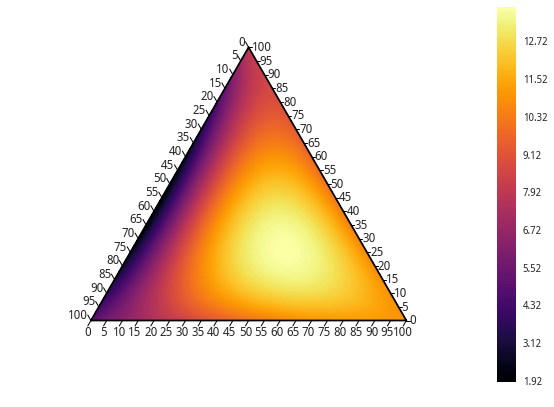

In [10]:
fig = spices_design.plot2D('test1',nlevels=200, subdiv=8, cmap=plt.cm.inferno)

### 例2，混凝土强度预测

![](images/ex2.png)
如图，混凝土用胶凝材料为水泥，矿粉，煤灰，其中水泥用量在25%以上，求单形重心试验方案。

这是一个约束设计问题，水泥用量25%以上，即$a_1\geq 0.25, a_2=a_3=0$。
编码矩阵Z为：
$$
\begin{align*}
\begin{bmatrix}
1 & 0.25 & 0.25 \\
0 & 0.75 & 0 \\
0 & 0 & 0.75
\end{bmatrix}
\end{align*}
$$


标上7个实验点，列出试验表并根据表来做实验得到结果：

试验号|A*|B*|C*|水泥_|矿粉_|煤灰_||强度(MPa)
:----:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|$x_1$|$x_2$|$x_3$|$z_1$|$z_2$|$z_3$|3d|28|180d
$y_1$|1|0|0|1|0|0|63.1|88.3|96
$y_2$|0|1|0|0.25|0.75|0|29.0|56.2|77
$y_3$|0|0|1|0.25|0|0.75|22.2|53.5|75.4
$y_{12}$|1/2|1/2|0|0.625|0.375|0|50.6|84.5|90.1
$y_{13}$|1/2|0|1/2|0.625|0|0.375|44.5|92.3|102
$y_{23}$|0|1/2|1/2|0.25|0.375|0.375|26.5|62.8|86
$y_{123}$|1/3|1/3|1/3|0.5|0.25|0.25|40.3|80.5|96.5

将结果和编码值代入公式2得：
$$
\begin{align*}
y_{3d}&=63.1x_1+29.0x_2+22.2x_3+18.2x_1 x_2+7.4x_1 x_3+3.6x_2 x_3−28.2x_1 x_2 x_3 \\
y_{28d}&=88.3x_1+56.2x_2+53.5x_3+49x_1 x_2+85.6x_1 x_3+31.8x_2 x_3−107.7x_1 x_2 x_3 \\
y_{180d}&=96x_1+77x_2+75.4x_3+14.9x_1 x_2+65.2x_1 x_3+39.2x_2 x_3+13.5x_1 x_2 x_3
\end{align*}
$$

对上面三式作三角坐标图，可以清晰地看出各组分对强度的贡献。从图中求出$x_1$,$x_2$,$x_3$坐标，再利用编码矩阵即可换算出实际各组分比例。另外，从3d与28d、180d对比，说明前期是水泥、矿粉对强度贡献大，后期煤灰贡献逐渐超过矿粉。
![](images/ex21.png)

In [11]:
concrete_design = simplex_center_designer_bounded(p=3, bounds=[.25, .0, .0])
y3 = {'1': 63.1, '2': 29.0, '3': 22.2, '12': 50.6,
      '13': 44.5, '23': 26.5, '123': 40.3}
y28 = {'1': 88.3, '2': 56.2, '3': 53.5, '12': 84.5,
       '13': 92.3, '23': 62.8, '123': 80.5}
y180 = {'1': 96, '2': 77, '3': 75.4, '12': 90.1,
        '13': 102, '23': 86, '123': 96.5}
concrete_design.make_yf('3d', y3)
concrete_design.make_yf('28d', y28)
concrete_design.make_yf('180d', y180)


(96, 77, 75.4, 14.399999999999977, 65.19999999999999, 39.19999999999999, 13.5)

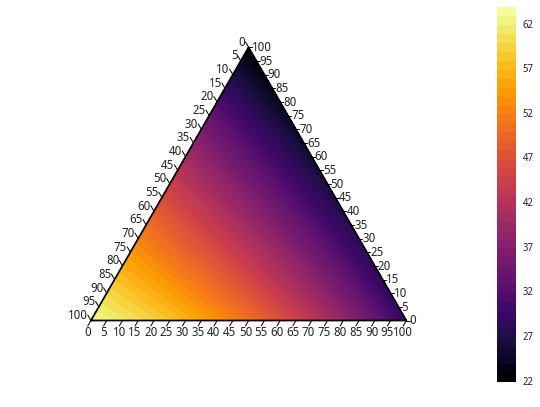

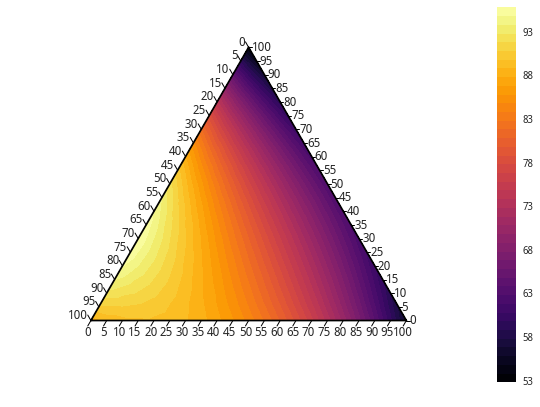

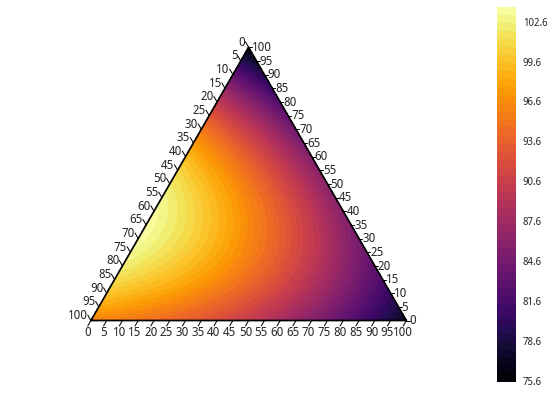

In [12]:
fig3d = concrete_design.plot2D(yname='3d', nlevels=50, subdiv=4, cmap=plt.cm.inferno)
fig28d = concrete_design.plot2D(yname='28d', nlevels=50, subdiv=4, cmap=plt.cm.inferno)
fig180d = concrete_design.plot2D(yname='180d', nlevels=50, subdiv=4, cmap=plt.cm.inferno)